### Iris dataset EDA
- Exploratory Data Analysis

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reading the CSV file
df = pd.read_csv("Iris.csv")

# Printing top 5 rows
print(df.head(5))

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [47]:
# drop the Id column
df = df.drop(['Id'], axis = 1) 

In [48]:
df.shape

(150, 5)

dataframe contains 6 columns and 150 rows.

In [49]:
df.info() # the columns and their data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


one column has categorical data and all the other columns are of the numeric type with non-Null entries.

In [50]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


count of each column along with their mean value, standard deviation, minimum and maximum values.

In [51]:
# Let’s see if our dataset contains any duplicates

duplicates = df[df.duplicated(keep=False)]

print(f"duplicates: \n{duplicates}")

#If dupl found, then use following
# data = df.drop_duplicates(subset ="Species",) # This is how u drop duplicates
# data

duplicates: 
     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm         Species
9              4.9           3.1            1.5           0.1     Iris-setosa
34             4.9           3.1            1.5           0.1     Iris-setosa
37             4.9           3.1            1.5           0.1     Iris-setosa
101            5.8           2.7            5.1           1.9  Iris-virginica
142            5.8           2.7            5.1           1.9  Iris-virginica


there are only three unique species

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


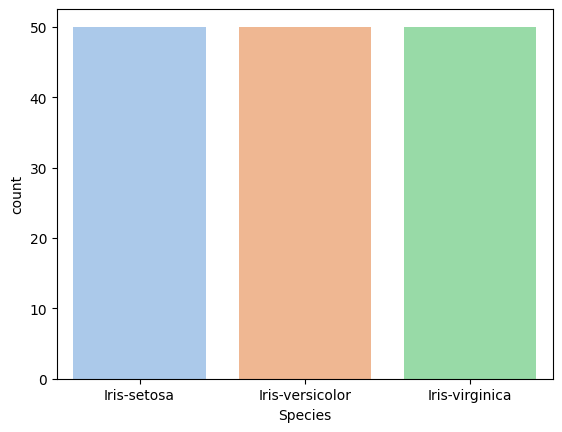

In [52]:
# Let’s see if the dataset is balanced or not i.e. all the species contain equal amounts of rows or not
print(df.value_counts("Species"))


# Lets visualize
# Our target column will be the Species column because at the end we will need the 
# result according to the species only. Let’s see a countplot for species.
sns.countplot(x='Species',
              palette='pastel', hue='Species', # TODO comment/uncomment
              data=df)
plt.show()

all the species contain an equal amount of rows, so we should not delete any entries.

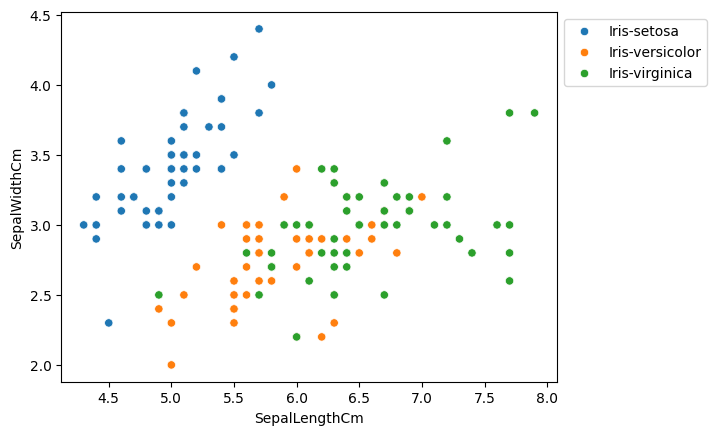

In [53]:
# We will see the relationship between the sepal length and sepal width and also between petal length and petal width.

# Example 1: Comparing Sepal Length and Sepal Width
sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm',
                hue='Species', # # TODO comment/uncomment
                data=df,
)

# Placing Legend outside the Figure
plt.legend(bbox_to_anchor=(1, 1), loc=2)

plt.show()

From the above plot, we can infer that
- Species Setosa has smaller sepal lengths but larger sepal widths.
- Species Versicolor lies in the middle of the other two species in terms of sepal length and width
- Species Virginica has larger sepal lengths but smaller sepal widths.

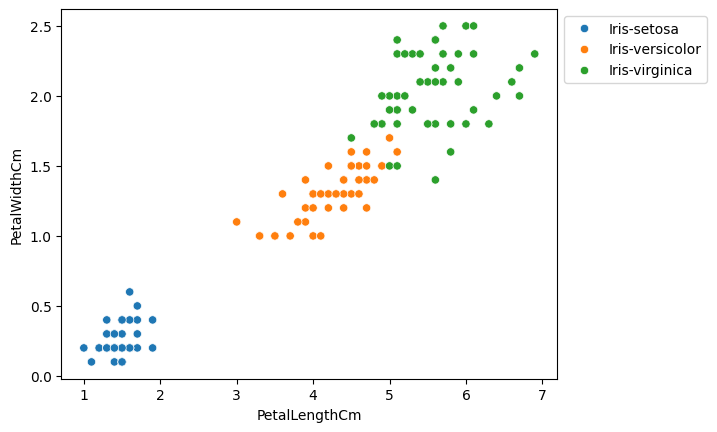

In [54]:
# Example 2: Comparing Petal Length and Petal Width

sns.scatterplot(x='PetalLengthCm', y='PetalWidthCm',
                hue='Species', # TODO uncomment/comment
                data=df,
               )

# Placing Legend outside the Figure
plt.legend(bbox_to_anchor=(1, 1), loc=2)

plt.show()

From the above plot, we can infer that – 

- Species Setosa has smaller petal lengths and widths.
- Versicolor Species lies in the middle of the other two species in terms of petal length and width
- Species Virginica has the largest of petal lengths and widths.

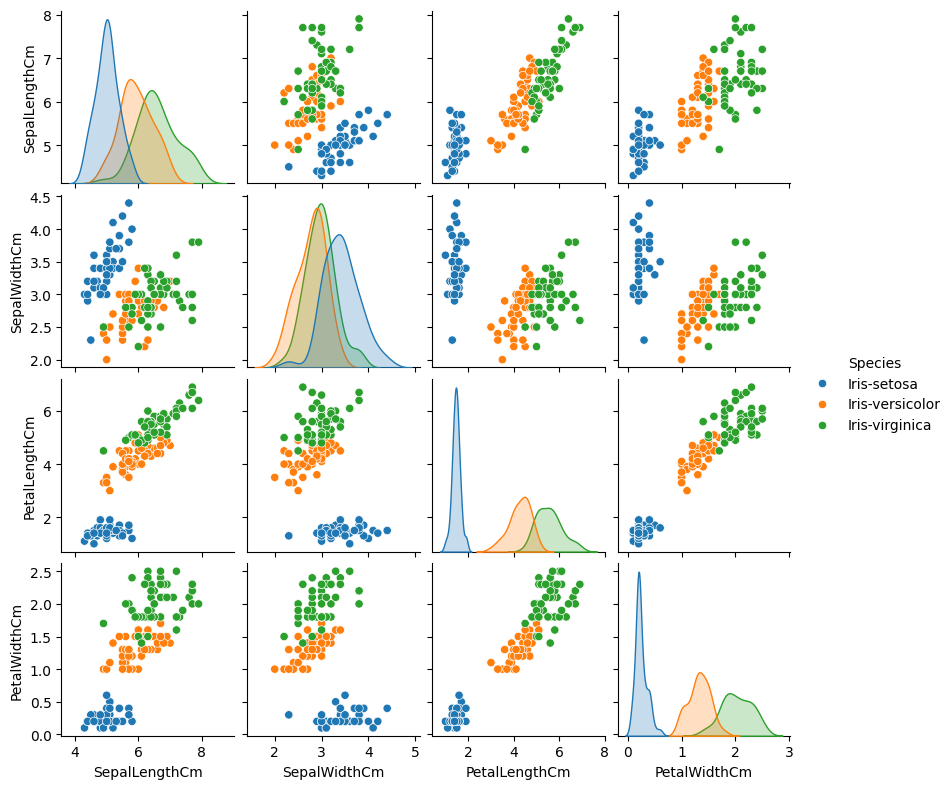

In [55]:
# Let’s plot all the column’s relationships using a pairplot. It can be used for multivariate analysis.

sns.pairplot(df, 
             hue='Species', # TODO comment it out
             height=2)

We can see many types of relationships from this plot such as the species Setosa has the smallest of petals widths and lengths. It also has the smallest sepal length but larger sepal widths. Such information can be gathered about any other species.

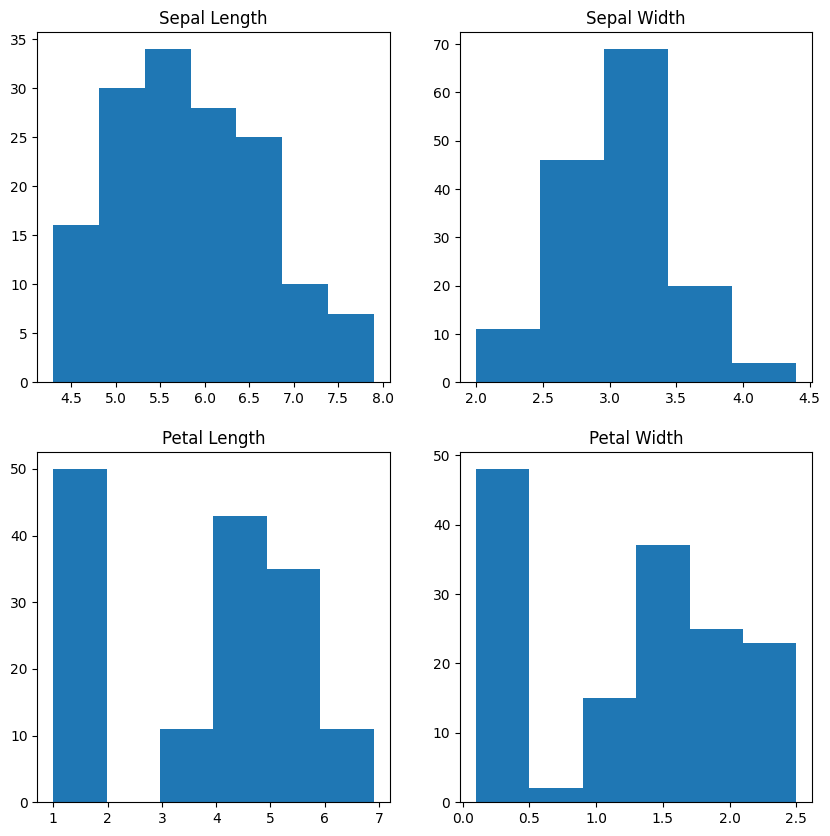

In [56]:
# Histograms allow seeing the distribution of data for various columns. It can be used for uni as well as bi-variate analysis.

fig, axes = plt.subplots(2, 2, figsize=(10,10))

axes[0,0].set_title("Sepal Length")
axes[0,0].hist(df['SepalLengthCm'], bins=7)

axes[0,1].set_title("Sepal Width")
axes[0,1].hist(df['SepalWidthCm'], bins=5);

axes[1,0].set_title("Petal Length")
axes[1,0].hist(df['PetalLengthCm'], bins=6);

axes[1,1].set_title("Petal Width")
axes[1,1].hist(df['PetalWidthCm'], bins=6);

From the above plot, we can see that – 

- The highest frequency of the sepal length is between 30 and 35 which is between 5.5 and 6
- The highest frequency of the sepal Width is around 70 which is between 3.0 and 3.5
- The highest frequency of the petal length is around 50 which is between 1 and 2
- The highest frequency of the petal width is between 40 and 50 which is between 0.0 and 0.5

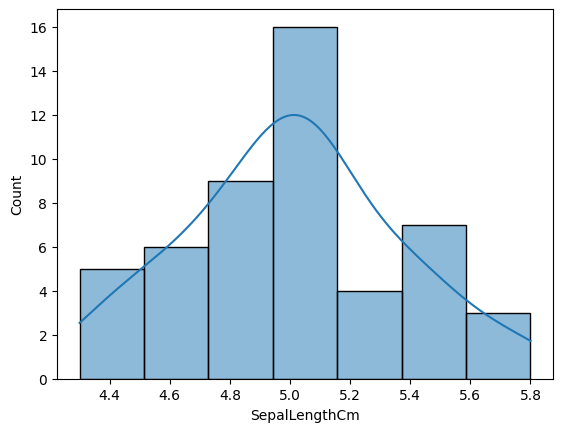

In [57]:
# Lest look at KDE of only one species 
df_setosa = df[df["Species"] == "Iris-setosa"]
sns.histplot(df_setosa["SepalLengthCm"], kde=True)
plt.show()

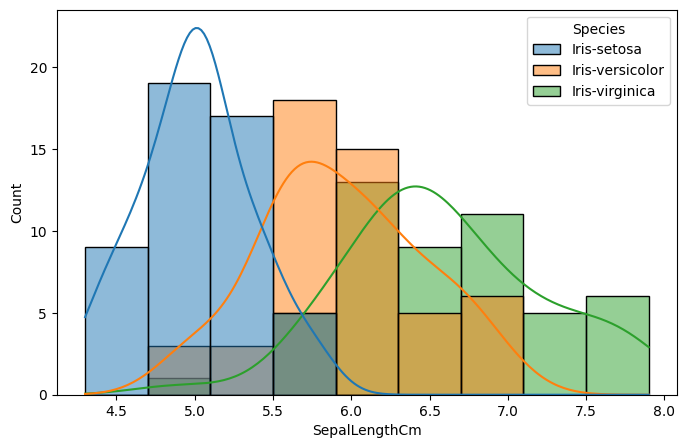

In [58]:
# lets plot kde of SepalLengthCm of 3 iris species
plt.figure(figsize=(8, 5))  # width=8, height=5
sns.histplot(data=df, x="SepalLengthCm", hue="Species", kde=True)
plt.show()

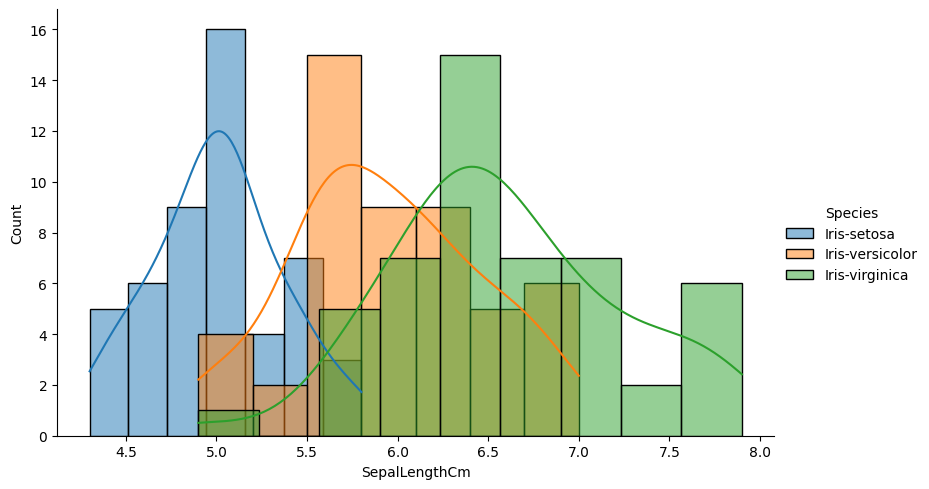

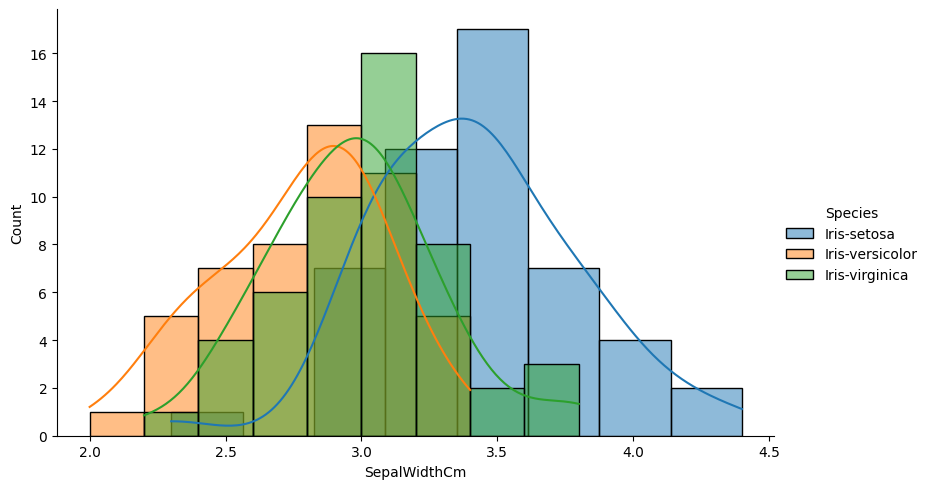

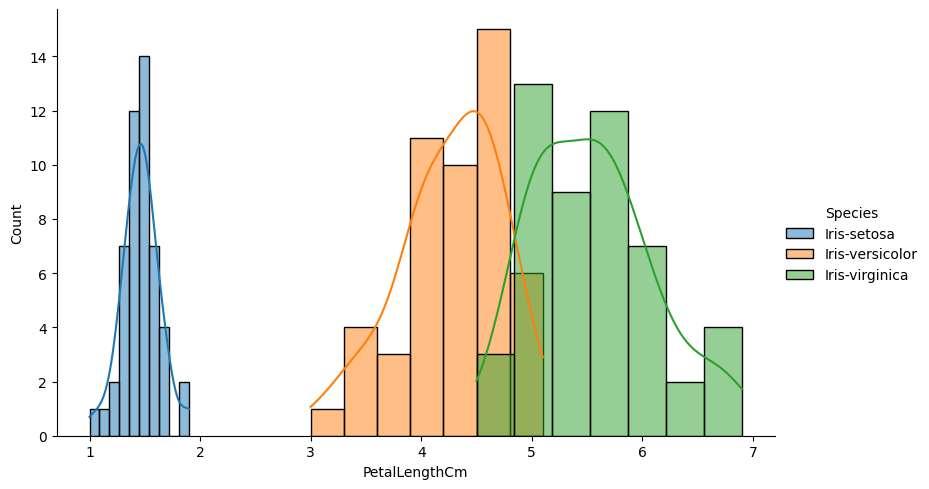

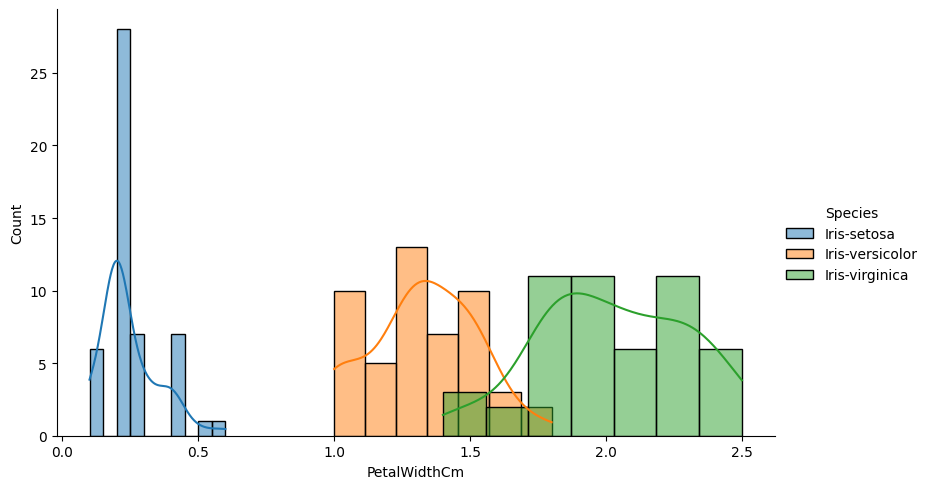

In [59]:
# Histograms with Distplot Plot

# Distplot is used basically for the univariant set of observations 
# and visualizes it through a histogram i.e. only one observation and
# hence we choose one particular column of the dataset.

# INSTRUCTIONS: PLOT EACH ONE SEPERATELY
# Set a wider figure size using height and aspect

# PLOT1
plot = sns.FacetGrid(df, hue="Species", height=5, aspect=1.6)
plot.map(sns.histplot, "SepalLengthCm", kde=True).add_legend()
plt.show()

# PLOT2
plot = sns.FacetGrid(df, hue="Species", height=5, aspect=1.6)
plot.map(sns.histplot, "SepalWidthCm", kde=True).add_legend()
plt.show()

# PLOT3
plot = sns.FacetGrid(df, hue="Species", height=5, aspect=1.6)
plot.map(sns.histplot, "PetalLengthCm", kde=True).add_legend()
plt.show()

# PLOT4
plot = sns.FacetGrid(df, hue="Species", height=5, aspect=1.6)
plot.map(sns.histplot, "PetalWidthCm", kde=True).add_legend()
plt.show()



From the above plots, we can see that – 

- In the case of Sepal Length, there is a huge amount of overlapping.
- In the case of Sepal Width also, there is a huge amount of overlapping.
- In the case of Petal Length, there is a very little amount of overlapping.
- In the case of Petal Width also, there is a very little amount of overlapping.

So we can use Petal Length and Petal Width as the classification feature.

In [60]:
# Pandas dataframe.corr() is used to find the pairwise correlation of all columns in
# the dataframe. Any NA values are automatically excluded. For any non-numeric data
# type columns in the dataframe it is ignored.

df.select_dtypes(include=['number']).corr(method='pearson')

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


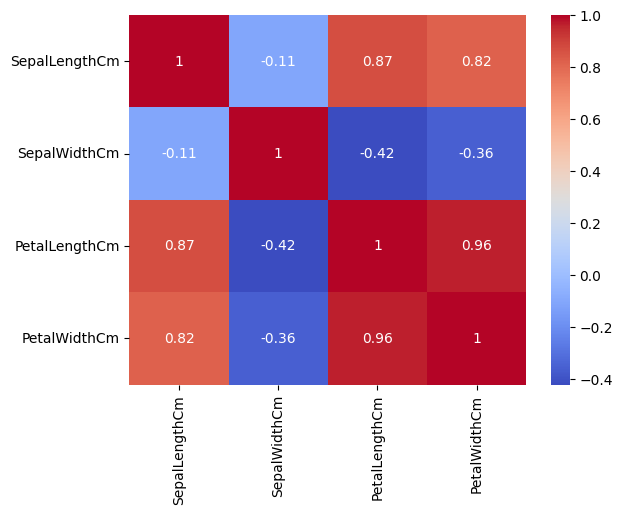

In [63]:
# The heatmap is a data visualization technique that is used to analyze the dataset as 
# colors in two dimensions. Basically, it shows a correlation between all numerical 
# variables in the dataset. In simpler terms, we can plot the above-found correlation 
# using the heatmaps.

sns.heatmap(  df.select_dtypes(include=['number']).corr(method='pearson'),
              cmap='coolwarm', \
			  annot = True);  

plt.show()

I want the graph to show only diagonal and below plots. So lets change the above code and then do the analysis after that

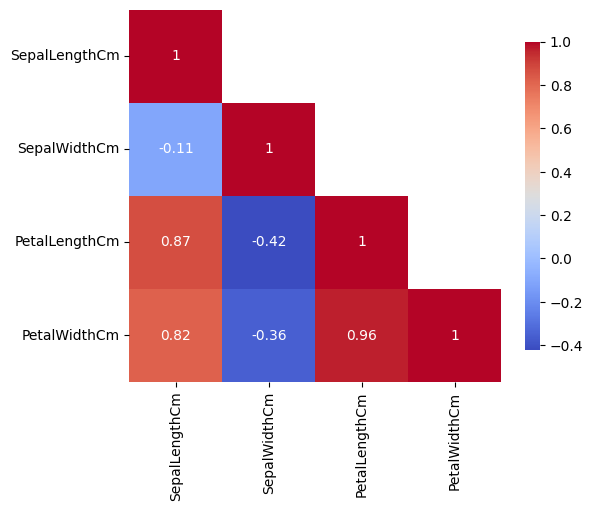

In [64]:
import numpy as np

# Assuming df is your DataFrame
corr_matrix = df.select_dtypes(include=['number']).corr(method='pearson')

# Create a mask for the upper triangle, excluding the diagonal
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(6, 5))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', square=True, cbar_kws={"shrink": .8})

plt.show()

From the above graph, we can see that –

- Petal width and petal length have high +ve correlations. 
- Petal length and sepal width have high +ve correlations.
- Petal Width and Sepal length have high +ve correlations.

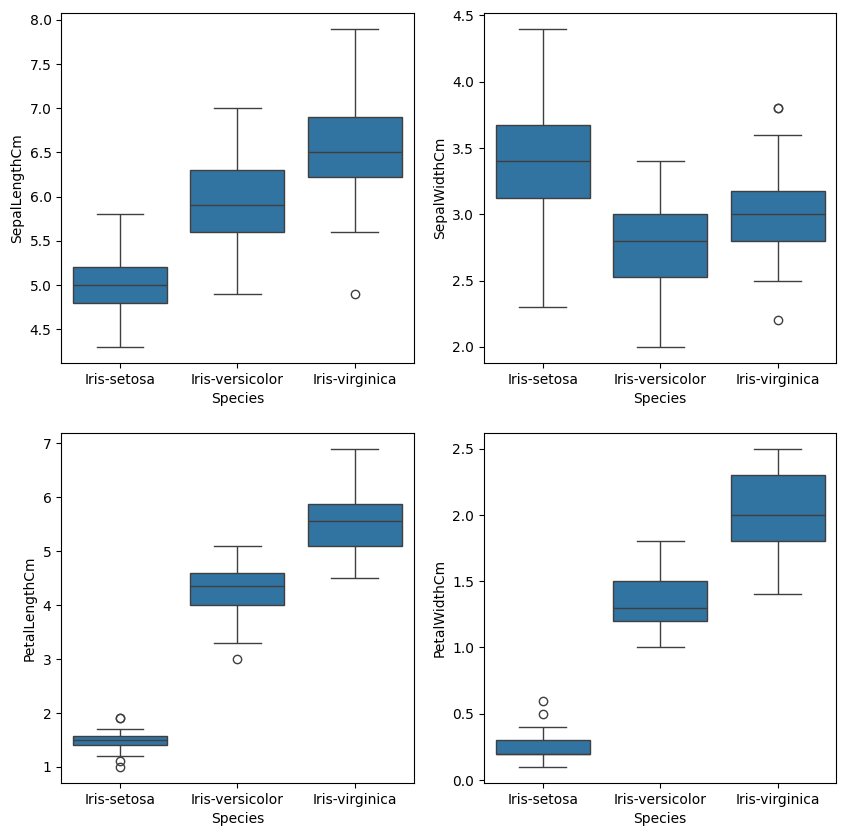

In [65]:
# We can use boxplots to see how the categorical value os distributed with other numerical values.

def graph(y):
    sns.boxplot(x="Species", y=y, data=df)

plt.figure(figsize=(10,10))
    
# Adding the subplot at the specified
# grid position
plt.subplot(221)
graph('SepalLengthCm')

plt.subplot(222)
graph('SepalWidthCm')

plt.subplot(223)
graph('PetalLengthCm')

plt.subplot(224)
graph('PetalWidthCm')

plt.show()

From the above graph, we can see that – 

- Species Setosa has values that are in narrow range for features SepalLength, PetalLength and PetalWidth and less distributed with some outliers.
- Species Versicolor has values that are in average range for features.
- Species Virginica has  values that are in narrow range for features

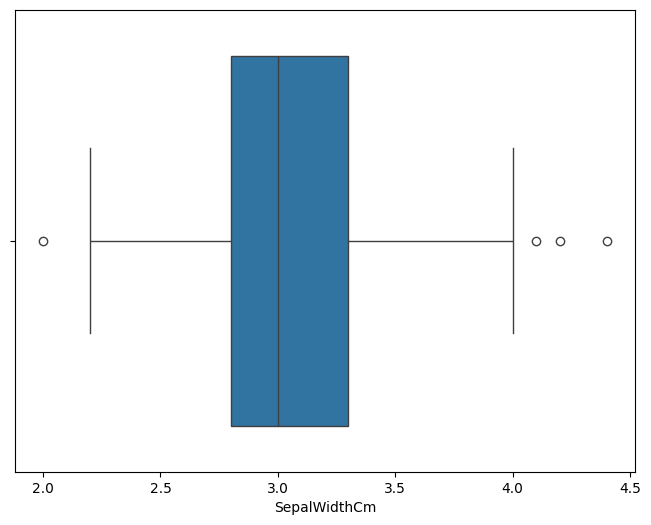

In [66]:
# The analysis for outlier detection is referred to as outlier mining.

# let’s plot the boxplot for the SepalWidthCm column.
plt.figure(figsize=(8, 6))

sns.boxplot(x='SepalWidthCm', data=df)
plt.show()

the values above 4 and below 2 are acting as outliers.

lower bound: 2.05
upper bound: 4.05
Outlier Data Points:
    SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm          Species
15            5.7           4.4            1.5           0.4      Iris-setosa
32            5.2           4.1            1.5           0.1      Iris-setosa
33            5.5           4.2            1.4           0.2      Iris-setosa
60            5.0           2.0            3.5           1.0  Iris-versicolor


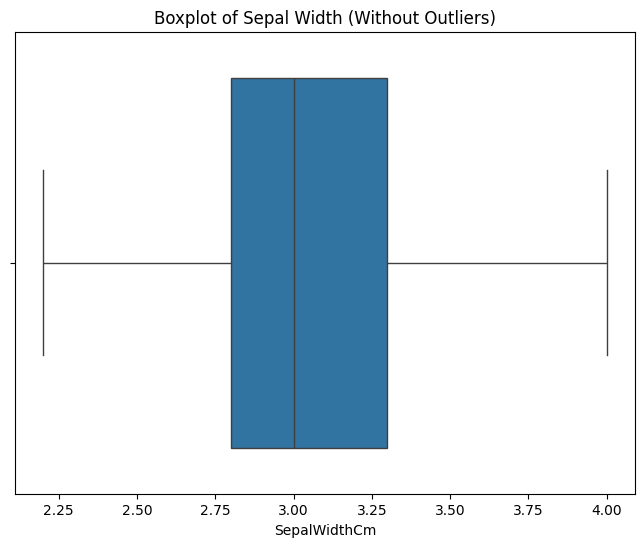

In [67]:
# For removing the outlier, one must follow the same process of removing an entry from the
# dataset using its exact position in the dataset because in all the above methods of 
# detecting the outliers end result is the list of all those data items that satisfy the 
# outlier definition according to the method used.

# Example: We will detect the outliers using IQR and then we will remove them. We will
# also draw the boxplot to see if the outliers are removed or not.

import numpy as np
# Step 2: Calculate the IQR to identify outliers
Q1 = df['SepalWidthCm'].quantile(0.25)
Q3 = df['SepalWidthCm'].quantile(0.75)
IQR = Q3 - Q1

# Define the bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"lower bound: {lower_bound}")
print(f"upper bound: {upper_bound}")

# Step 3: Find the outliers and filter the DataFrame to remove outliers
df_outliers = df[(df['SepalWidthCm'] < lower_bound) | (df['SepalWidthCm'] > upper_bound)]
df_no_outliers = df[(df['SepalWidthCm'] >= lower_bound) & (df['SepalWidthCm'] <= upper_bound)]

# Display the outliers
print(f"Outlier Data Points:\n{df_outliers}")

# Optional: Visualize the data without outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x='SepalWidthCm', data=df_no_outliers)
plt.title('Boxplot of Sepal Width (Without Outliers)')
plt.show()


df = df_no_outliers